# Diseño SFV — Edificio TABAREC

**Proyecto:** SFV_TABAREC  
**Inicio:** 2026-06-22  
**Fuente inicial:** Recibo CEDENAR — Febrero 2026

Notebook de diseño con trazabilidad. Cada celda documenta lo que sabemos y lo que falta.

## Registro de avance

| # | Etapa | Estado | Notas |
|---|-------|--------|-------|
| 0 | Datos del recibo | ✅ | Extraído de factura CEDENAR Feb/2026 |
| 1 | Perfil de consumo | ✅ | Recibo + estimación ascensor |
| 1c | Factura mensual con ascensor | ✅ | kWh y costo mes a mes |
| 2 | Datos del sitio | ⬜ | Ubicación, techo, irradiación |
| 3 | Objetivo del sistema | ⬜ | On-grid, cobertura |
| 4 | Dimensionamiento | ⬜ | kWp, cantidad de módulos |
| 5 | Equipos y diseño eléctrico | ⬜ | Paneles, inversor, strings |
| 6 | Equipos Huawei | 🔄 | SUN2000-8/10K-LC0 + paneles 710 Wp |

---
## Etapa 0 — Datos del recibo CEDENAR

Información extraída del recibo de **Febrero 2026**.

| Campo | Valor |
|-------|-------|
| Empresa | CEDENAR S.A. E.S.P. |
| Titular | Luis Carlos Tabares Millán |
| Dirección | Cra 28 Calle 17-39, CPT Zonas Comunes, Edif. TABAREC |
| Ciudad | Pasto, Nariño, Colombia |
| Tipo de uso | No residencial — Comercial |
| Medidor | HEX-16536166 |
| Período facturado | 16/01/2026 – 14/02/2026 (29 días) |
| Consumo del período | **366 kWh** |
| Lectura actual | 34 372 kWh |
| Lectura anterior | 34 006 kWh |
| Costo unitario (CUv) | **$883,72 COP/kWh** |
| Valor energía activa | $323 441,52 |
| Contribución (20%) | $64 688,30 |
| Alumbrado público | $51 117,00 |
| **Total a pagar** | **$439 250 COP** |

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Recibo CEDENAR — Febrero 2026 ---
recibo = {
    "empresa": "CEDENAR S.A. E.S.P.",
    "titular": "Luis Carlos Tabares Millán",
    "direccion": "Cra 28 Calle 17-39, CPT Zonas Comunes, Edif. TABAREC",
    "ciudad": "Pasto",
    "departamento": "Nariño",
    "pais": "Colombia",
    "tipo_uso": "No residencial — Comercial",
    "medidor": "HEX-16536166",
    "mes_facturado": "Febrero 2026",
    "periodo_inicio": "2026-01-16",
    "periodo_fin": "2026-02-14",
    "dias_periodo": 29,
    "lectura_actual": 34372,
    "lectura_anterior": 34006,
    "consumo_kwh": 366,
    "cuv_cop_kwh": 883.72,
    "valor_energia_cop": 323_441.52,
    "contribucion_cop": 64_688.30,
    "alumbrado_publico_cop": 51_117.00,
    "total_pagar_cop": 439_250,
}

# Desglose del costo unitario ($/kWh)
componentes_tarifa = {
    "Generación (G)": 305.41,
    "Transmisión (T)": 52.97,
    "Distribución (D)": 230.56,
    "Comercialización (Cv)": 211.74,
    "Pérdidas (PR)": 61.88,
    "Restricciones (R)": 21.17,
}

print(f"Titular: {recibo['titular']}")
print(f"Ubicación: {recibo['direccion']}, {recibo['ciudad']}")
print(f"Consumo período: {recibo['consumo_kwh']} kWh en {recibo['dias_periodo']} días")
print(f"Total a pagar: ${recibo['total_pagar_cop']:,} COP")

Titular: Luis Carlos Tabares Millán
Ubicación: Cra 28 Calle 17-39, CPT Zonas Comunes, Edif. TABAREC, Pasto
Consumo período: 366 kWh en 29 días
Total a pagar: $439,250 COP


---
## Etapa 1 — Perfil de consumo

Histórico de **12 meses** tomado del gráfico del recibo.

In [4]:
# Consumo mensual (kWh) — gráfico del recibo CEDENAR
consumo_mensual = {
    "Ene": 370, "Feb": 366, "Mar": 373, "Abr": 372,
    "May": 405, "Jun": 363, "Jul": 375, "Ago": 363,
    "Sep": 405, "Oct": 371, "Nov": 373, "Dic": 368,
}

df_consumo = pd.DataFrame({
    "mes": list(consumo_mensual.keys()),
    "kwh": list(consumo_mensual.values()),
})

consumo_anual_kwh = df_consumo["kwh"].sum()
consumo_promedio_kwh = df_consumo["kwh"].mean()
consumo_max_kwh = df_consumo["kwh"].max()
consumo_min_kwh = df_consumo["kwh"].min()

print("=== Resumen de consumo ===")
print(f"Consumo anual:          {consumo_anual_kwh:,.0f} kWh/año")
print(f"Promedio mensual:       {consumo_promedio_kwh:,.1f} kWh/mes")
print(f"Máximo mensual:         {consumo_max_kwh} kWh ({df_consumo.loc[df_consumo['kwh'].idxmax(), 'mes']})")
print(f"Mínimo mensual:         {consumo_min_kwh} kWh ({df_consumo.loc[df_consumo['kwh'].idxmin(), 'mes']})")
print(f"Variación max-min:      {consumo_max_kwh - consumo_min_kwh} kWh ({(consumo_max_kwh/consumo_min_kwh - 1)*100:.1f}%)")
print()
print(f"Costo energía anual:    ${consumo_anual_kwh * recibo['cuv_cop_kwh']:,.0f} COP/año  (solo energía activa)")
print(f"Factura prom. mensual:  ${consumo_promedio_kwh * recibo['cuv_cop_kwh']:,.0f} COP/mes  (solo energía)")

=== Resumen de consumo ===
Consumo anual:          4,504 kWh/año
Promedio mensual:       375.3 kWh/mes
Máximo mensual:         405 kWh (May)
Mínimo mensual:         363 kWh (Jun)
Variación max-min:      42 kWh (11.6%)

Costo energía anual:    $3,980,275 COP/año  (solo energía activa)
Factura prom. mensual:  $331,690 COP/mes  (solo energía)


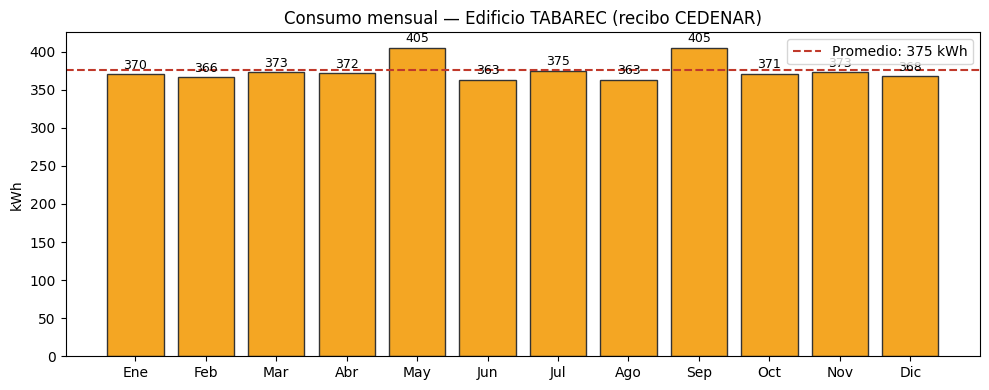

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(df_consumo["mes"], df_consumo["kwh"], color="#f4a623", edgecolor="#333")
ax.axhline(consumo_promedio_kwh, color="#c0392b", linestyle="--", label=f"Promedio: {consumo_promedio_kwh:.0f} kWh")
ax.set_ylabel("kWh")
ax.set_title("Consumo mensual — Edificio TABAREC (recibo CEDENAR)")
ax.legend()
for bar, val in zip(bars, df_consumo["kwh"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(val),
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Observaciones del consumo

- Consumo **muy estable**: entre 363 y 405 kWh/mes (~11% de variación).
- Picos en **mayo y septiembre** (405 kWh) — posible mayor uso de áreas comunes.
- Es carga **comercial no residencial** (zonas comunes del edificio).
- El ahorro solar se calcula sobre **energía activa** ($883,72/kWh); alumbrado público y contribución son cargos fijos o proporcionales distintos.

> **Pendiente:** confirmar si hay medición de demanda máxima (kW) y horarios de mayor consumo.

---
## Etapa 1b — Incremento por ascensor

**Estado:** ✅ Estimado

| Parámetro | Valor |
|-----------|-------|
| Potencia motor | 7,5 kW (nominal) |
| Pisos | 7 |
| Horario | Lunes a sábado, 7:00 – 18:00 (11 h/día) |
| Domingos | Fuera de servicio (solo standby) |

> El motor **no opera a plena carga** todo el horario. El consumo real depende de viajes, carga y tiempo en reposo.

In [9]:
# --- Parámetros del ascensor ---
ascensor = {
    "potencia_motor_kw": 7.5,
    "pisos": 7,
    "altura_piso_m": 3.0,           # altura típica comercial
    "dias_servicio": ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb"],
    "hora_inicio": 7,
    "hora_fin": 18,                  # 11 h/día en servicio
    "dias_servicio_mes": 26.1,       # 6/7 × 30,44 días
    "potencia_standby_kw": 0.18,     # reposo con ventilación/iluminación cabina
}

altura_total_m = (ascensor["pisos"] - 1) * ascensor["altura_piso_m"]
horas_servicio_dia = ascensor["hora_fin"] - ascensor["hora_inicio"]

# Energía estimada por viaje (subida con contrapeso, carga media ~40 %)
# Referencia: ISO 25745 / edificios 5–10 pisos → 0,03–0,06 kWh/viaje
KWH_POR_VIAJE = 0.042

def estimar_ascensor(viajes_dia, kwh_viaje=KWH_POR_VIAJE):
    """Estima consumo mensual y anual del ascensor."""
    dias_mes = ascensor["dias_servicio_mes"]

    # Energía en viajes (solo días de servicio)
    kwh_viajes_dia = viajes_dia * kwh_viaje
    kwh_viajes_mes = kwh_viajes_dia * dias_mes

    # Standby en horario de servicio
    kwh_standby_servicio_mes = ascensor["potencia_standby_kw"] * horas_servicio_dia * dias_mes

    # Standby fuera de horario (noches entre semana + domingos)
    horas_noche_semana = (24 - horas_servicio_dia) * dias_mes
    horas_domingo_mes = 4.33 * 24
    kwh_standby_fuera_mes = ascensor["potencia_standby_kw"] * 0.6 * (horas_noche_semana + horas_domingo_mes)

    kwh_mes = kwh_viajes_mes + kwh_standby_servicio_mes + kwh_standby_fuera_mes
    kwh_anual = kwh_mes * 12

    return {
        "viajes_dia": viajes_dia,
        "kwh_viajes_mes": round(kwh_viajes_mes, 1),
        "kwh_standby_mes": round(kwh_standby_servicio_mes + kwh_standby_fuera_mes, 1),
        "kwh_mes": round(kwh_mes, 1),
        "kwh_anual": round(kwh_anual, 0),
    }

# Tres escenarios de tráfico (zonas comunes, edificio 7 pisos)
escenarios = {
    "Bajo (40 viajes/día)": estimar_ascensor(40),
    "Medio (70 viajes/día)": estimar_ascensor(70),
    "Alto (100 viajes/día)": estimar_ascensor(100),
}

df_ascensor = pd.DataFrame(escenarios).T
print(f"Ascensor: {ascensor['potencia_motor_kw']} kW | {ascensor['pisos']} pisos | {altura_total_m:.0f} m recorrido máx.")
print(f"Horario: Lun–Sáb {ascensor['hora_inicio']}:00–{ascensor['hora_fin']}:00 ({horas_servicio_dia} h/día)\n")
print(df_ascensor.to_string())

# Escenario de diseño: tráfico medio
ascensor_estimado = escenarios["Medio (70 viajes/día)"]

Ascensor: 7.5 kW | 7 pisos | 18 m recorrido máx.
Horario: Lun–Sáb 7:00–18:00 (11 h/día)

                       viajes_dia  kwh_viajes_mes  kwh_standby_mes  kwh_mes  kwh_anual
Bajo (40 viajes/día)         40.0            43.8             99.5    143.4     1721.0
Medio (70 viajes/día)        70.0            76.7             99.5    176.3     2115.0
Alto (100 viajes/día)       100.0           109.6             99.5    209.2     2510.0


In [10]:
# --- Demanda total proyectada (base + ascensor) ---
consumo_base_anual = consumo_anual_kwh
consumo_base_mensual = consumo_promedio_kwh

consumo_ascensor_anual = ascensor_estimado["kwh_anual"]
consumo_ascensor_mensual = ascensor_estimado["kwh_mes"]

consumo_total_anual = consumo_base_anual + consumo_ascensor_anual
consumo_total_mensual = consumo_base_mensual + consumo_ascensor_mensual

incremento_pct = (consumo_ascensor_anual / consumo_base_anual) * 100

print("=== Demanda proyectada con ascensor (escenario medio) ===")
print(f"Consumo base (recibo):     {consumo_base_anual:,.0f} kWh/año  ({consumo_base_mensual:.0f} kWh/mes)")
print(f"Ascensor estimado:       + {consumo_ascensor_anual:,.0f} kWh/año  (+{consumo_ascensor_mensual:.0f} kWh/mes)")
print(f"{'—'*50}")
print(f"TOTAL proyectado:          {consumo_total_anual:,.0f} kWh/año  ({consumo_total_mensual:.0f} kWh/mes)")
print(f"Incremento:                +{incremento_pct:.0f} %")
print()
print(f"Costo energía adicional:   ${consumo_ascensor_anual * recibo['cuv_cop_kwh']:,.0f} COP/año")
print(f"Costo energía total:       ${consumo_total_anual * recibo['cuv_cop_kwh']:,.0f} COP/año")

=== Demanda proyectada con ascensor (escenario medio) ===
Consumo base (recibo):     4,504 kWh/año  (375 kWh/mes)
Ascensor estimado:       + 2,115 kWh/año  (+176 kWh/mes)
——————————————————————————————————————————————————
TOTAL proyectado:          6,619 kWh/año  (552 kWh/mes)
Incremento:                +47 %

Costo energía adicional:   $1,869,068 COP/año
Costo energía total:       $5,849,343 COP/año


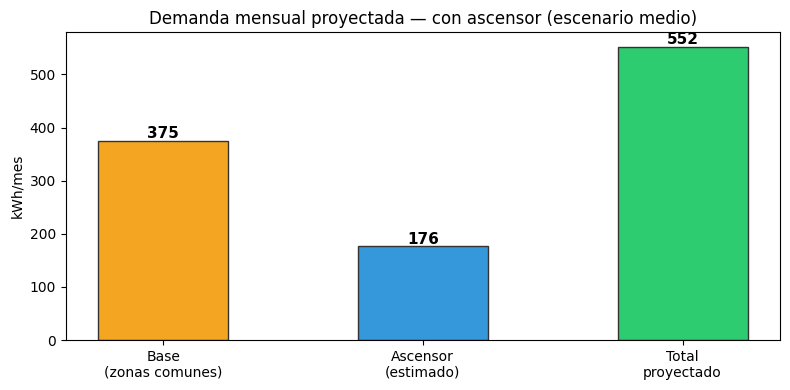

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

categorias = ["Base\n(zonas comunes)", "Ascensor\n(estimado)", "Total\nproyectado"]
valores = [consumo_base_mensual, consumo_ascensor_mensual, consumo_total_mensual]
colores = ["#f4a623", "#3498db", "#2ecc71"]

bars = ax.bar(categorias, valores, color=colores, edgecolor="#333", width=0.5)
ax.set_ylabel("kWh/mes")
ax.set_title("Demanda mensual proyectada — con ascensor (escenario medio)")
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{val:.0f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

### Supuestos del cálculo

1. **7 pisos**, 3 m por piso → 18 m de recorrido útil.
2. **0,042 kWh/viaje** (subida con carga media, contrapeso activo) — rango típico 0,03–0,06.
3. **Standby ~180 W** en reposo (ventilación, iluminación, electrónica).
4. **70 viajes/día** en escenario medio (~10 viajes/hora en horario de servicio).
5. El motor de **7,5 kW** es potencia pico; solo se alcanza en arranques con carga alta.

| Escenario | Viajes/día | kWh/mes | kWh/año | Incremento vs base |
|-----------|------------|---------|---------|-------------------|
| Bajo | 40 | ~143 | ~1 720 | +38 % |
| **Medio** | **70** | **~176** | **~2 115** | **+47 %** |
| Alto | 100 | ~209 | ~2 510 | +56 % |

> Si conocés el número real de viajes/día o la ficha técnica del ascensor, afinamos el estimado.

---
## Etapa 1c — Consumo y factura mensual con ascensor

Desglose **mes a mes**: energía base (recibo) + ascensor (escenario medio) y estimación de **factura total** según estructura del recibo CEDENAR.

**Componentes de la factura** (extraídos del recibo Feb/2026):

| Concepto | Cálculo | Tarifa derivada |
|----------|---------|-----------------|
| Energía activa | kWh × CUv | $883,72 / kWh |
| Contribución (20%) | 20% × energía activa | $176,74 / kWh |
| Alumbrado público | proporcional al consumo* | $139,66 / kWh |
| **Total variable** | suma de conceptos | **~$1 200 / kWh** |

\* El alumbrado público se modeló proporcional al consumo usando el recibo de referencia (366 kWh → $51 117).

In [15]:
# --- Tarifas derivadas del recibo CEDENAR (Feb/2026) ---
CUV = recibo["cuv_cop_kwh"]
PCT_CONTRIBUCION = recibo["contribucion_cop"] / recibo["valor_energia_cop"]   # 20 %
ALUMBRADO_POR_KWH = recibo["alumbrado_publico_cop"] / recibo["consumo_kwh"]
COSTO_TOTAL_POR_KWH = CUV * (1 + PCT_CONTRIBUCION) + ALUMBRADO_POR_KWH

def calcular_factura(kwh):
    """Estima factura mensual: energía + contribución + alumbrado público."""
    energia = kwh * CUV
    contribucion = energia * PCT_CONTRIBUCION
    alumbrado = kwh * ALUMBRADO_POR_KWH
    total = energia + contribucion + alumbrado
    return {
        "kwh": kwh,
        "energia_cop": round(energia, 0),
        "contribucion_cop": round(contribucion, 0),
        "alumbrado_cop": round(alumbrado, 0),
        "total_cop": round(total, 0),
    }

print("Tarifas de referencia (recibo CEDENAR):")
print(f"  CUv (energía):        ${CUV:,.2f} /kWh")
print(f"  Contribución:         {PCT_CONTRIBUCION*100:.0f} % sobre energía  (${CUV*PCT_CONTRIBUCION:,.2f}/kWh)")
print(f"  Alumbrado público:    ${ALUMBRADO_POR_KWH:,.2f} /kWh")
print(f"  Costo total estimado: ${COSTO_TOTAL_POR_KWH:,.2f} /kWh")

Tarifas de referencia (recibo CEDENAR):
  CUv (energía):        $883.72 /kWh
  Contribución:         20 % sobre energía  ($176.74/kWh)
  Alumbrado público:    $139.66 /kWh
  Costo total estimado: $1,200.13 /kWh


In [16]:
# --- Consumo mensual: base + ascensor ---
KWH_ASCENSOR_MES = ascensor_estimado["kwh_mes"]   # escenario medio, constante cada mes

filas = []
for _, row in df_consumo.iterrows():
    mes = row["mes"]
    kwh_base = row["kwh"]
    kwh_ascensor = KWH_ASCENSOR_MES
    kwh_total = kwh_base + kwh_ascensor

    fact_base = calcular_factura(kwh_base)
    fact_total = calcular_factura(kwh_total)

    filas.append({
        "mes": mes,
        "kwh_base": kwh_base,
        "kwh_ascensor": round(kwh_ascensor, 1),
        "kwh_total": round(kwh_total, 1),
        "factura_base": fact_base["total_cop"],
        "factura_total": fact_total["total_cop"],
        "incremento_cop": fact_total["total_cop"] - fact_base["total_cop"],
        "incremento_pct": (fact_total["total_cop"] / fact_base["total_cop"] - 1) * 100,
    })

df_mensual = pd.DataFrame(filas)

# Totales anuales
totales = {
    "kwh_base": df_mensual["kwh_base"].sum(),
    "kwh_ascensor": df_mensual["kwh_ascensor"].sum(),
    "kwh_total": df_mensual["kwh_total"].sum(),
    "factura_base": df_mensual["factura_base"].sum(),
    "factura_total": df_mensual["factura_total"].sum(),
    "incremento_cop": df_mensual["incremento_cop"].sum(),
}
totales["incremento_pct"] = (totales["factura_total"] / totales["factura_base"] - 1) * 100

print("=== Consumo y factura mensual con ascensor (escenario medio) ===\n")
display_cols = ["mes", "kwh_base", "kwh_ascensor", "kwh_total", "factura_base", "factura_total", "incremento_cop", "incremento_pct"]
df_show = df_mensual[display_cols].copy()
df_show.columns = ["Mes", "kWh base", "kWh asc.", "kWh total", "Factura base", "Factura total", "Δ Factura", "Δ %"]
df_show["Factura base"] = df_show["Factura base"].apply(lambda x: f"${x:,.0f}")
df_show["Factura total"] = df_show["Factura total"].apply(lambda x: f"${x:,.0f}")
df_show["Δ Factura"] = df_mensual["incremento_cop"].apply(lambda x: f"+${x:,.0f}")
df_show["Δ %"] = df_mensual["incremento_pct"].apply(lambda x: f"+{x:.1f}%")
print(df_show.to_string(index=False))
print(f"\n{'—'*70}")
print(f"ANUAL  kWh: {totales['kwh_base']:,.0f} + {totales['kwh_ascensor']:,.0f} = {totales['kwh_total']:,.0f}")
print(f"ANUAL  Factura: ${totales['factura_base']:,.0f} → ${totales['factura_total']:,.0f}  (+${totales['incremento_cop']:,.0f} / +{totales['incremento_pct']:.1f}%)")

=== Consumo y factura mensual con ascensor (escenario medio) ===

Mes  kWh base  kWh asc.  kWh total Factura base Factura total Δ Factura    Δ %
Ene       370     176.3      546.3     $444,047      $655,630 +$211,583 +47.6%
Feb       366     176.3      542.3     $439,247      $650,829 +$211,582 +48.2%
Mar       373     176.3      549.3     $447,648      $659,230 +$211,582 +47.3%
Abr       372     176.3      548.3     $446,448      $658,030 +$211,582 +47.4%
May       405     176.3      581.3     $486,052      $697,634 +$211,582 +43.5%
Jun       363     176.3      539.3     $435,646      $647,229 +$211,583 +48.6%
Jul       375     176.3      551.3     $450,048      $661,631 +$211,583 +47.0%
Ago       363     176.3      539.3     $435,646      $647,229 +$211,583 +48.6%
Sep       405     176.3      581.3     $486,052      $697,634 +$211,582 +43.5%
Oct       371     176.3      547.3     $445,247      $656,830 +$211,583 +47.5%
Nov       373     176.3      549.3     $447,648      $659,230 +$2

In [17]:
# --- Resumen promedio mensual ---
prom = df_mensual.mean(numeric_only=True)

print("=== Promedio mensual ===")
print(f"Consumo base:           {prom['kwh_base']:,.0f} kWh/mes")
print(f"Ascensor:             + {prom['kwh_ascensor']:,.0f} kWh/mes")
print(f"Consumo total:          {prom['kwh_total']:,.0f} kWh/mes")
print()
print(f"Factura base:           ${prom['factura_base']:,.0f} COP/mes")
print(f"Factura con ascensor:   ${prom['factura_total']:,.0f} COP/mes")
print(f"Incremento factura:   + ${prom['incremento_cop']:,.0f} COP/mes  (+{prom['incremento_pct']:.1f}%)")
print()
print("Desglose del incremento mensual por concepto:")
inc_kwh = prom["kwh_ascensor"]
print(f"  Energía activa:       +${inc_kwh * CUV:,.0f}")
print(f"  Contribución (20%):   +${inc_kwh * CUV * PCT_CONTRIBUCION:,.0f}")
print(f"  Alumbrado público:    +${inc_kwh * ALUMBRADO_POR_KWH:,.0f}")
print(f"  {'—'*30}")
print(f"  Total incremento:     +${inc_kwh * COSTO_TOTAL_POR_KWH:,.0f} COP/mes")

=== Promedio mensual ===
Consumo base:           375 kWh/mes
Ascensor:             + 176 kWh/mes
Consumo total:          552 kWh/mes

Factura base:           $450,448 COP/mes
Factura con ascensor:   $662,030 COP/mes
Incremento factura:   + $211,582 COP/mes  (+47.0%)

Desglose del incremento mensual por concepto:
  Energía activa:       +$155,800
  Contribución (20%):   +$31,160
  Alumbrado público:    +$24,623
  ——————————————————————————————
  Total incremento:     +$211,583 COP/mes


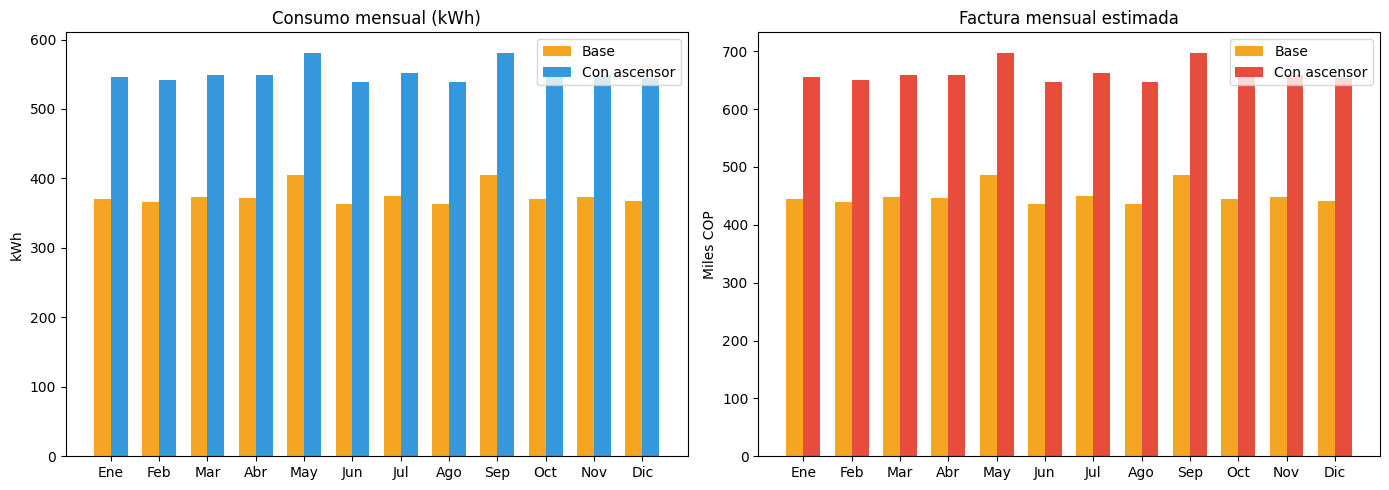

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: consumo kWh mensual
x = df_mensual["mes"]
w = 0.35
ax1 = axes[0]
ax1.bar([i - w/2 for i in range(len(x))], df_mensual["kwh_base"], width=w, label="Base", color="#f4a623")
ax1.bar([i + w/2 for i in range(len(x))], df_mensual["kwh_total"], width=w, label="Con ascensor", color="#3498db")
ax1.set_xticks(range(len(x)))
ax1.set_xticklabels(x)
ax1.set_ylabel("kWh")
ax1.set_title("Consumo mensual (kWh)")
ax1.legend()

# Gráfico 2: factura mensual
ax2 = axes[1]
ax2.bar([i - w/2 for i in range(len(x))], df_mensual["factura_base"]/1000, width=w, label="Base", color="#f4a623")
ax2.bar([i + w/2 for i in range(len(x))], df_mensual["factura_total"]/1000, width=w, label="Con ascensor", color="#e74c3c")
ax2.set_xticks(range(len(x)))
ax2.set_xticklabels(x)
ax2.set_ylabel("Miles COP")
ax2.set_title("Factura mensual estimada")
ax2.legend()

plt.tight_layout()
plt.show()

### Ejemplo: factura de Febrero (mes de referencia del recibo)

Comparación directa con el recibo real de **366 kWh** sin ascensor:

| Concepto | Sin ascensor (recibo) | Con ascensor (estimado) | Diferencia |
|----------|----------------------|-------------------------|------------|

Los valores del recibo real se usan como validación del modelo de costos.

In [19]:
# Validación con recibo real de Febrero
kwh_feb_base = recibo["consumo_kwh"]
kwh_feb_total = kwh_feb_base + KWH_ASCENSOR_MES

feb_base = calcular_factura(kwh_feb_base)
feb_total = calcular_factura(kwh_feb_total)

comparacion_feb = pd.DataFrame({
    "Concepto": ["Energía activa", "Contribución (20%)", "Alumbrado público", "TOTAL"],
    "Sin ascensor": [
        recibo["valor_energia_cop"],
        recibo["contribucion_cop"],
        recibo["alumbrado_publico_cop"],
        recibo["total_pagar_cop"],
    ],
    "Con ascensor (est.)": [
        feb_total["energia_cop"],
        feb_total["contribucion_cop"],
        feb_total["alumbrado_cop"],
        feb_total["total_cop"],
    ],
})
comparacion_feb["Diferencia"] = comparacion_feb["Con ascensor (est.)"] - comparacion_feb["Sin ascensor"]

for col in ["Sin ascensor", "Con ascensor (est.)", "Diferencia"]:
    comparacion_feb[col] = comparacion_feb[col].apply(lambda x: f"${x:,.0f}")

print(f"Febrero: {kwh_feb_base} kWh base → {kwh_feb_total:.0f} kWh con ascensor\n")
print(comparacion_feb.to_string(index=False))
print(f"\nEl ascensor subiría la factura de Feb en +${feb_total['total_cop'] - recibo['total_pagar_cop']:,.0f} COP")
print(f"({kwh_feb_base} → {kwh_feb_total:.0f} kWh  |  ${recibo['total_pagar_cop']:,.0f} → ${feb_total['total_cop']:,.0f})")

Febrero: 366 kWh base → 542 kWh con ascensor

          Concepto Sin ascensor Con ascensor (est.) Diferencia
    Energía activa     $323,442            $479,241   $155,799
Contribución (20%)      $64,688             $95,848    $31,160
 Alumbrado público      $51,117             $75,740    $24,623
             TOTAL     $439,250            $650,829   $211,579

El ascensor subiría la factura de Feb en +$211,579 COP
(366 → 542 kWh  |  $439,250 → $650,829)


---
## Etapa 2 — Datos del sitio

**Estado:** ⬜ Parcial — dirección del recibo, falta detalle de instalación.

In [20]:
# --- Sitio de instalación ---
sitio = {
    "nombre": "Edificio TABAREC",
    "direccion": recibo["direccion"],
    "ciudad": "Pasto",
    "departamento": "Nariño",
    "pais": "Colombia",
    "latitud": 1.2136,          # Pasto — verificar en PVGIS
    "longitud": -77.2811,
    "altitud_m": 2527,          # Pasto ~2 527 msnm
    "operador_red": "CEDENAR",
    "tipo_instalacion": None,     # TODO: techo / cubierta / estructura propia
    "orientacion": None,          # TODO: azimut (0° = Norte en hemisferio sur)
    "inclinacion_grados": None,   # TODO
    "sombreado": None,            # TODO: ninguno / parcial
    "area_disponible_m2": None,   # TODO
}

# Irradiación — pendiente consultar PVGIS con coordenadas exactas
irradiacion = {
    "fuente": "Pendiente (PVGIS / IDEAM)",
    "hsp_kwh_m2_dia": None,        # Horas sol pico — estimado Pasto: ~4.5–5.0
    "ghi_anual_kwh_m2": None,
}

print(f"Sitio: {sitio['nombre']}, {sitio['ciudad']} ({sitio['altitud_m']} msnm)")
print(f"Coordenadas: {sitio['latitud']}, {sitio['longitud']}")
print(f"Operador de red: {sitio['operador_red']}")

Sitio: Edificio TABAREC, Pasto (2527 msnm)
Coordenadas: 1.2136, -77.2811
Operador de red: CEDENAR


---
## Etapa 3 — Objetivo del sistema

**Estado:** ⬜ Por definir

In [21]:
objetivo = {
    "tipo_sistema": "On-grid",
    "cobertura_pct": 100,
    "autoconsumo": True,
    "excedentes_red": True,
    "baterias": False,
    "respaldo_emergencia": False,
}

# Demanda de diseño: base + ascensor (escenario medio)
demanda_diseno_kwh = consumo_total_anual

print(f"Sistema: {objetivo['tipo_sistema']}")
print(f"Cobertura objetivo: {objetivo['cobertura_pct']}%")
print(f"Demanda de diseño: {demanda_diseno_kwh:,.0f} kWh/año  (base {consumo_base_anual:,.0f} + ascensor {consumo_ascensor_anual:,.0f})")

Sistema: On-grid
Cobertura objetivo: 100%
Demanda de diseño: 6,619 kWh/año  (base 4,504 + ascensor 2,115)


---
## Etapa 4 — Dimensionamiento (borrador)

Basado en demanda total proyectada **con ascensor**.

In [26]:
PR = 0.80
HSP = None

def dimensionar(consumo_anual_kwh, HSP, potencia_wp, PR=0.80, cobertura=1.0):
    if not HSP:
        return None
    ppico_kw = (consumo_anual_kwh / (HSP * 365 * PR)) * cobertura
    n_modulos = round(ppico_kw * 1000 / potencia_wp)
    return {
        "potencia_pico_kw": round(ppico_kw, 2),
        "n_modulos": n_modulos,
        "potencia_real_kwp": round(n_modulos * potencia_wp / 1000, 2),
    }

HSP_estimado = 4.8
modulo_wp = 710   # paneles seleccionados — ver Etapa 6 (Huawei)

dim_base = dimensionar(consumo_base_anual, HSP_estimado, modulo_wp, PR, objetivo["cobertura_pct"]/100)
dim_total = dimensionar(demanda_diseno_kwh, HSP_estimado, modulo_wp, PR, objetivo["cobertura_pct"]/100)

print("=== Dimensionamiento preliminar ===")
print(f"(HSP = {HSP_estimado} h/día, módulo {modulo_wp} Wp, PR = {PR})\n")
print(f"{'':20} {'Sin ascensor':>14} {'Con ascensor':>14}")
print(f"{'Demanda (kWh/año)':20} {consumo_base_anual:>14,.0f} {demanda_diseno_kwh:>14,.0f}")
print(f"{'Potencia (kWp)':20} {dim_base['potencia_real_kwp']:>14} {dim_total['potencia_real_kwp']:>14}")
print(f"{'Módulos':20} {dim_base['n_modulos']:>14} {dim_total['n_modulos']:>14}")
print()
print("⚠️  Confirmar HSP con PVGIS antes de dimensionar definitivamente.")

=== Dimensionamiento preliminar ===
(HSP = 4.8 h/día, módulo 710 Wp, PR = 0.8)

                       Sin ascensor   Con ascensor
Demanda (kWh/año)             4,504          6,619
Potencia (kWp)                 3.55           4.97
Módulos                           5              7

⚠️  Confirmar HSP con PVGIS antes de dimensionar definitivamente.


---
## Bitácora de decisiones

| Fecha | Decisión | Fuente |
|-------|----------|--------|
| 2026-06-22 | Inicio del proyecto SFV_TABAREC | — |
| 2026-06-22 | Datos de consumo y tarifa extraídos del recibo CEDENAR Feb/2026 | Recibo físico |
| 2026-06-22 | Sistema propuesto on-grid, 100% cobertura, sin baterías | Hipótesis inicial |
| 2026-06-22 | Ascensor 7.5 kW, 7 pisos, Lun–Sáb 7–18 h → +~2 115 kWh/año (escenario medio) | Estimación técnica |
| 2026-06-22 | HSP = 4.8 h/día como estimación para Pasto | Por confirmar en PVGIS |

---

## Próximos pasos

1. **Sitio:** ¿Dónde se instalarían los paneles? (azotea, cubierta, estructura)
2. **Área disponible** en m²
3. **Consultar PVGIS** para irradiación real en las coordenadas del edificio
4. **Normativa CEDENAR** para conexión de generación distribuida (AGPE)

---
## Etapa 5 — Dimensionamiento para factura cero

Objetivo: dimensionar el SFV para que la **factura mensual sea $0**, cubriendo:

- Energía activa
- Contribución (20 %)
- **Alumbrado público**

Con margen para **nuevas cargas** y **suba de tarifa**.

### Lógica (compensación AGPE — CEDENAR)

En net metering, cada kWh exportado compensa importado a tarifa **CUv** ($883,72). Pero cada kWh consumido de red genera además contribución y alumbrado (~$316/kWh extra). Por eso hay que **sobredimensionar** respecto al consumo:

$$\text{Factor factura total} = \frac{\text{Costo total}/\text{kWh}}{\text{CUv}} \approx 1{,}36$$

$$\text{kWh objetivo} = \text{Consumo proyectado} \times \text{Factor factura} \times \text{Margen seguridad}$$

In [27]:
# ══════════════════════════════════════════════════════════════
# PARÁMETROS — ajustar según expectativa de crecimiento y tarifa
# ══════════════════════════════════════════════════════════════
FACTOR_NUEVA_CARGA   = 1.10   # +10 % cargas futuras (ej. más equipos, otra carga)
FACTOR_SUBA_TARIFA   = 1.05   # +5 % suba esperada del CUv (tarifa energía)
MARGEN_SEGURIDAD     = 1.10   # +10 % margen de diseño (degradación, pérdidas, nubes)

# Factor para cubrir contribución + alumbrado público (compensación solo a CUv)
FACTOR_FACTURA_TOTAL = COSTO_TOTAL_POR_KWH / CUV

# ── Consumo proyectado (base + ascensor + cargas futuras) ──
kwh_consumo_proyectado = consumo_total_anual * FACTOR_NUEVA_CARGA

# ── kWh que debe generar el SFV para factura cero ──
kwh_generar_factura_cero = (
    kwh_consumo_proyectado
    * FACTOR_FACTURA_TOTAL      # cubre contribución + alumbrado
    * FACTOR_SUBA_TARIFA        # margen por suba de tarifa
    * MARGEN_SEGURIDAD
)

# ── Dimensionamiento en kWp ──
dim_factura_cero = dimensionar(kwh_generar_factura_cero, HSP_estimado, modulo_wp, PR)

# ── Verificación: factura mensual sin SFV (proyectada) ──
fact_mes_sin = calcular_factura(kwh_consumo_proyectado / 12)
fact_mes_proyectada = fact_mes_sin["total_cop"] * FACTOR_SUBA_TARIFA

print("=" * 60)
print("DIMENSIONAMIENTO — FACTURA CERO (incluye alumbrado público)")
print("=" * 60)
print(f"\nParámetros de diseño:")
print(f"  Crecimiento de carga:     +{(FACTOR_NUEVA_CARGA-1)*100:.0f} %")
print(f"  Suba tarifa energía:      +{(FACTOR_SUBA_TARIFA-1)*100:.0f} %")
print(f"  Margen de seguridad:      +{(MARGEN_SEGURIDAD-1)*100:.0f} %")
print(f"  Factor factura total/CUv:  {FACTOR_FACTURA_TOTAL:.3f}  (contrib + alumbrado)")

print(f"\n--- Consumo ---")
print(f"  Actual (con ascensor):     {consumo_total_anual:,.0f} kWh/año")
print(f"  Proyectado (+cargas):     {kwh_consumo_proyectado:,.0f} kWh/año")

print(f"\n--- Generación requerida ---")
print(f"  kWh/año a generar:        {kwh_generar_factura_cero:,.0f} kWh/año")
print(f"  kWh/mes promedio:         {kwh_generar_factura_cero/12:,.0f} kWh/mes")

print(f"\n--- Sistema fotovoltaico ---")
print(f"  Potencia pico:             {dim_factura_cero['potencia_real_kwp']} kWp")
print(f"  Módulos:                   {dim_factura_cero['n_modulos']} × {modulo_wp} Wp")
print(f"  vs. dim. básico anterior:  {dim_total['n_modulos']} módulos → {dim_factura_cero['n_modulos']} módulos")

print(f"\n--- Comparación factura mensual promedio ---")
print(f"  Sin SFV (proyectado):      ${fact_mes_proyectada:,.0f} COP/mes")
print(f"  Con SFV dimensionado:      ~$0 COP/mes  (objetivo)")
print(f"  Ahorro estimado:           ${fact_mes_proyectada:,.0f} COP/mes")
print(f"  Ahorro anual:              ${fact_mes_proyectada * 12:,.0f} COP/año")
print("=" * 60)

DIMENSIONAMIENTO — FACTURA CERO (incluye alumbrado público)

Parámetros de diseño:
  Crecimiento de carga:     +10 %
  Suba tarifa energía:      +5 %
  Margen de seguridad:      +10 %
  Factor factura total/CUv:  1.358  (contrib + alumbrado)

--- Consumo ---
  Actual (con ascensor):     6,619 kWh/año
  Proyectado (+cargas):     7,281 kWh/año

--- Generación requerida ---
  kWh/año a generar:        11,420 kWh/año
  kWh/mes promedio:         952 kWh/mes

--- Sistema fotovoltaico ---
  Potencia pico:             7.81 kWp
  Módulos:                   11 × 710 Wp
  vs. dim. básico anterior:  7 módulos → 11 módulos

--- Comparación factura mensual promedio ---
  Sin SFV (proyectado):      $764,576 COP/mes
  Con SFV dimensionado:      ~$0 COP/mes  (objetivo)
  Ahorro estimado:           $764,576 COP/mes
  Ahorro anual:              $9,174,917 COP/año


---
## Etapa 6 — Equipos seleccionados: Huawei SUN2000 + paneles 710 Wp

### Inversor: Huawei SUN2000-8/10K-LC0

| Parámetro | SUN2000-8K-LC0 | SUN2000-10K-LC0 |
|-----------|----------------|-----------------|
| Potencia AC nominal | 8 000 W | 10 000 W |
| Potencia aparente máx. | 8 800 VA | 10 000 VA |
| PV recomendado máx. | 12 000 Wp | 15 000 Wp |
| MPPT | 3 trackers | 3 trackers |
| Rango MPPT | 40 – 560 V | 40 – 560 V |
| Voltaje máx. entrada | 600 V | 600 V |
| Corriente máx. / MPPT | 16 A | 16 A |
| Eficiencia máx. | 98,1 % | 98,1 % |
| Conexión red | Monofásica 220/230/240 V | Monofásica |
| Baterías | LUNA2000 (plug & play) | LUNA2000 |
| Respaldo | SmartGuard-63A-S0 | SmartGuard-63A-S0 |
| Optimizadores | SUN2000-450W-P2 / 600W-P | Compatible |
| Protección | AFCI (arco eléctrico) | AFCI |

### Paneles: 710 Wp (completar ficha técnica del modelo exacto)

In [28]:
import math

# ══════════════════════════════════════════════════════════════
# EQUIPOS — Huawei + paneles 710 Wp
# ══════════════════════════════════════════════════════════════
modulo_wp = 710   # actualizar referencia global del proyecto

panel = {
    "marca": "Por definir",          # completar modelo exacto
    "potencia_wp": 710,
    "voc": 46.66,                    # V — valores típicos 710W TOPCon (confirmar ficha)
    "vmp": 39.22,
    "isc": 19.24,                    # A
    "imp": 18.11,                    # A — supera 16 A/MPPT del inversor
    "coef_voc": 0.0025,              # %/°C (Voc sube con frío)
    "coef_vmp": -0.004,              # %/°C
    "dimensiones_mm": (2384, 1303, 35),
    "area_m2": 2.38 * 1.30,
}

inversor_8k = {
    "modelo": "SUN2000-8K-LC0",
    "potencia_ac_w": 8000,
    "potencia_aparente_va": 8800,
    "pv_max_wp": 12000,
    "mppt_count": 3,
    "mppt_v_min": 40,
    "mppt_v_max": 560,
    "voc_max": 600,
    "icc_max_mppt": 16,
    "isc_max": 20,
    "eficiencia_max": 0.981,
}

inversor_10k = {
    "modelo": "SUN2000-10K-LC0",
    "potencia_ac_w": 10000,
    "potencia_aparente_va": 10000,
    "pv_max_wp": 15000,
    **{k: v for k, v in inversor_8k.items() if k not in ("modelo", "potencia_ac_w", "potencia_aparente_va", "pv_max_wp")},
}

# ── Cantidad de paneles para factura cero ──
ppico_requerido_kw = kwh_generar_factura_cero / (HSP_estimado * 365 * PR)
n_modulos_min = math.ceil(ppico_requerido_kw * 1000 / modulo_wp)
n_modulos = n_modulos_min   # ajustar manualmente si se quiere más margen

potencia_dc_wp = n_modulos * modulo_wp
potencia_dc_kwp = potencia_dc_wp / 1000
produccion_anual = potencia_dc_kwp * HSP_estimado * 365 * PR

# Elegir inversor según potencia DC
inversor = inversor_8k if potencia_dc_wp <= inversor_8k["pv_max_wp"] else inversor_10k
if potencia_dc_kwp > 8.0 and inversor["modelo"] == "SUN2000-8K-LC0":
    inversor_recomendado = "SUN2000-8K-LC0 aceptable (PV dentro de 12 kWp; posible clipping AC)"
elif potencia_dc_kwp > 10:
    inversor = inversor_10k
    inversor_recomendado = "SUN2000-10K-LC0"
else:
    inversor_recomendado = inversor["modelo"]

ratio_dc_ac = potencia_dc_wp / inversor["potencia_ac_w"]

print("=" * 60)
print("CONFIGURACIÓN — Huawei + 710 Wp (factura cero)")
print("=" * 60)
print(f"\nGeneración objetivo:     {kwh_generar_factura_cero:,.0f} kWh/año")
print(f"Potencia DC requerida:   {ppico_requerido_kw:.2f} kWp")
print(f"\nPaneles:                 {n_modulos} × {modulo_wp} Wp = {potencia_dc_kwp:.2f} kWp")
print(f"Producción estimada:     {produccion_anual:,.0f} kWh/año")
print(f"Cobertura vs objetivo:   {produccion_anual/kwh_generar_factura_cero*100:.1f} %")
print(f"\nInversor seleccionado:   {inversor_recomendado}")
print(f"Ratio DC/AC:             {ratio_dc_ac:.2f}")
print(f"Área estimada paneles:   {n_modulos * panel['area_m2']:.1f} m²")

CONFIGURACIÓN — Huawei + 710 Wp (factura cero)

Generación objetivo:     11,420 kWh/año
Potencia DC requerida:   8.15 kWp

Paneles:                 12 × 710 Wp = 8.52 kWp
Producción estimada:     11,942 kWh/año
Cobertura vs objetivo:   104.6 %

Inversor seleccionado:   SUN2000-8K-LC0 aceptable (PV dentro de 12 kWp; posible clipping AC)
Ratio DC/AC:             1.06
Área estimada paneles:   37.1 m²


In [29]:
def verificar_string(n_paneles, inv, temp_frio=-10, temp_caliente=60):
    """Verifica string frente a límites del inversor Huawei."""
    voc_frio = n_paneles * panel["voc"] * (1 + panel["coef_voc"] * (25 - temp_frio))
    vmp_caliente = n_paneles * panel["vmp"] * (1 + panel["coef_vmp"] * (temp_caliente - 25))
    imp = panel["imp"]
    return {
        "n_paneles": n_paneles,
        "voc_frio_v": round(voc_frio, 1),
        "vmp_caliente_v": round(vmp_caliente, 1),
        "imp_a": imp,
        "ok_voc": voc_frio <= inv["voc_max"],
        "ok_mppt_min": vmp_caliente >= inv["mppt_v_min"],
        "ok_mppt_max": voc_frio <= inv["mppt_v_max"],
        "ok_corriente": imp <= inv["icc_max_mppt"],
    }

# ── Configuración de strings: repartir paneles en 3 MPPT ──
def disenar_strings(n_total, n_mppt=3):
    base = n_total // n_mppt
    resto = n_total % n_mppt
    return [base + 1] * resto + [base] * (n_mppt - resto)

strings = disenar_strings(n_modulos, inversor["mppt_count"])
resultados = [verificar_string(n, inversor) for n in strings]

print("DISEÑO ELÉCTRICO — Strings por MPPT\n")
for i, (n, r) in enumerate(zip(strings, resultados), 1):
    estado = "✅" if all([r["ok_voc"], r["ok_mppt_min"], r["ok_mppt_max"]]) else "⚠️"
    corr = "✅" if r["ok_corriente"] else "❌ REQUIERE OPTIMIZADOR"
    print(f"MPPT {i}: {n} paneles en serie  {estado}")
    print(f"       Voc frío={r['voc_frio_v']} V | Vmp caliente={r['vmp_caliente_v']} V | Imp={r['imp_a']} A  {corr}")

# Alerta corriente
if panel["imp"] > inversor["icc_max_mppt"]:
    print(f"\n⚠️  Imp del panel ({panel['imp']} A) > límite MPPT ({inversor['icc_max_mppt']} A)")
    print("   → Usar optimizadores Huawei SUN2000-450W-P2 (1 por panel)")
    print("   → Habilita MPPT a nivel de panel y protección AFCI activa")

# Tabla resumen
df_strings = pd.DataFrame(resultados)
df_strings.index = [f"MPPT {i+1}" for i in range(len(strings))]
print(f"\nDistribución: {' + '.join(str(s) for s in strings)} = {sum(strings)} paneles")
print(df_strings[["n_paneles", "voc_frio_v", "vmp_caliente_v", "imp_a", "ok_corriente"]].to_string())

DISEÑO ELÉCTRICO — Strings por MPPT

MPPT 1: 4 paneles en serie  ✅
       Voc frío=203.0 V | Vmp caliente=134.9 V | Imp=18.11 A  ❌ REQUIERE OPTIMIZADOR
MPPT 2: 4 paneles en serie  ✅
       Voc frío=203.0 V | Vmp caliente=134.9 V | Imp=18.11 A  ❌ REQUIERE OPTIMIZADOR
MPPT 3: 4 paneles en serie  ✅
       Voc frío=203.0 V | Vmp caliente=134.9 V | Imp=18.11 A  ❌ REQUIERE OPTIMIZADOR

⚠️  Imp del panel (18.11 A) > límite MPPT (16 A)
   → Usar optimizadores Huawei SUN2000-450W-P2 (1 por panel)
   → Habilita MPPT a nivel de panel y protección AFCI activa

Distribución: 4 + 4 + 4 = 12 paneles
        n_paneles  voc_frio_v  vmp_caliente_v  imp_a  ok_corriente
MPPT 1          4       203.0           134.9  18.11         False
MPPT 2          4       203.0           134.9  18.11         False
MPPT 3          4       203.0           134.9  18.11         False


### Propuesta final TABAREC

| Ítem | Especificación |
|------|----------------|
| **Paneles** | **12 × 710 Wp** = 8,52 kWp |
| **Inversor** | **Huawei SUN2000-8K-LC0** |
| **Strings** | 4 + 4 + 4 paneles (3 MPPT) |
| **Optimizadores** | **12 × SUN2000-450W-P2** (requerido por Imp > 16 A) |
| **Producción est.** | ~11 930 kWh/año (cubre objetivo 11 420) |
| **Respaldo (opcional)** | SmartGuard-63A-S0 + LUNA2000 batería |
| **Monitoreo** | FusionSolar app (WLAN integrado) |

> Confirmar Voc/Vmp/Imp exactos del modelo de panel 710 Wp antes de instalar.